<a href="https://colab.research.google.com/github/Raegar7zzz/Machine-Learning-NYU/blob/main/ML_Spring_25_Lab_1_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1:  Simple linear regression for one independent variable

In this lab, you will load data, plot data, perform simple mathematical manipulations, and fit a simple linear regression model.  Before doing this lab, you can go through the class demo on simple linear regression for an automobile dataset.  This lab uses the Boston housing data set, a widely-used machine learning data set for illustrating basic concepts.  

## Loading the data

The Boston housing data set was collected in the 1970s to study the relationship between house price and various factors such as the house size, crime rate, socio-economic status, etc.  Since the variables are easy to understand, the data set is ideal for learning basic concepts in machine learning.  The raw data and a complete description of the dataset used to be found on the UCI website: https://archive.ics.uci.edu/ml/machine-learning-databases. Now it's part of the sklearn datasets.

Each row in the dataset it not a single house -- it corresponds to the average information about homes in a single single [census track](https://en.wikipedia.org/wiki/Census_tract).

In the lab, you will complete all the code marked `TODO`.

I have supplied a list `names` of the column headers.  You will have to set the options in the `read_csv` command to correctly delimit the data in the file and name the columns correctly.

In [1]:
# prompt: import boston into a dataframe

import pandas as pd
from sklearn.datasets import fetch_openml

# Fetch the Boston Housing dataset
boston = fetch_openml(name='Boston', version=1, as_frame=True)
X = boston.data
y = boston.target
print("The feature names are")
print(boston.feature_names)


# Create a DataFrame
boston_df = pd.DataFrame(data=X, columns=boston.feature_names)
boston_df['target'] = y


The feature names are
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [17]:
# print the top 10 records on the dataframe
print(boston_df.head(10))

      CRIM    ZN  INDUS CHAS    NOX     RM    AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575   65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421   78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185   61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998   45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147   54.2  6.0622   3  222.0     18.7   
5  0.02985   0.0   2.18    0  0.458  6.430   58.7  6.0622   3  222.0     18.7   
6  0.08829  12.5   7.87    0  0.524  6.012   66.6  5.5605   5  311.0     15.2   
7  0.14455  12.5   7.87    0  0.524  6.172   96.1  5.9505   5  311.0     15.2   
8  0.21124  12.5   7.87    0  0.524  5.631  100.0  6.0821   5  311.0     15.2   
9  0.17004  12.5   7.87    0  0.524  6.004   85.9  6.5921   5  311.0     15.2   

        B  LSTAT  target  
0  396.90   4.98    24.0  
1  396.90   9.14    21.6  
2  392.83   4.03    34.7  


Display the first six rows of the data frame

In [20]:
print(boston_df.head(6))
# TODO

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   
5  0.02985   0.0   2.18    0  0.458  6.430  58.7  6.0622   3  222.0     18.7   

        B  LSTAT  target  
0  396.90   4.98    24.0  
1  396.90   9.14    21.6  
2  392.83   4.03    34.7  
3  394.63   2.94    33.4  
4  396.90   5.33    36.2  
5  394.12   5.21    28.7  


## Basic Manipulations on the Data

What is the shape of the data?  How many attributes are there?  How many samples?
Print a statement of the form:

    num samples=xxx, num attributes=yy

In [21]:
# Get the shape of the DataFrame
rows, cols = boston_df.shape

# Print the number of samples and attributes
print(f"num samples={rows}, num attributes={cols}")



num samples=506, num attributes=14


Create a response vector `y` with the values in the column `PRICE`.  The vector `y` should be a 1D `numpy.ndarray` structure.

In [24]:
# TODO
# y = ...
# Rename the 'target' column to 'PRICE'
boston_df.rename(columns={"target": "PRICE"}, inplace=True)

# Now you can extract it as a 1D NumPy array
y = boston_df["PRICE"].values


Use the response vector `y` to find the mean house price in thousands and the fraction of homes that are above $40k. (You may realize this is very cheap.  Prices have gone up a lot since the 1970s!). Print and label your results. Create print statements of the form:

`The mean house price is xx.yy thousands of dollars.`

`Only x.y percent are above $40k`


In [25]:
import numpy as np

# Assuming `y` is already defined as the target (house price in thousands)
mean_price = np.mean(y)
fraction_above_40k = np.mean(y > 40)  # This returns the fraction of homes priced above 40k

print(f"The mean house price is {mean_price:.2f} thousands of dollars.")
print(f"Only {fraction_above_40k * 100:.1f} percent are above $40k")


The mean house price is 22.53 thousands of dollars.
Only 6.1 percent are above $40k


## Visualizing the Data

Load the `matplotlib` package with the following commands.

In [7]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

Similar to the `y` vector, create a predictor vector `x` containing the values in the `RM` column, which represents the average number of rooms in each census track.

In [26]:
# TODO
# x = ...
# Create the predictor vector x from the RM column
x = boston_df["RM"].values


Create a scatter plot of the price vs. the `RM` attribute.  Label the axes with reasonable labels so that someone else can understand the plot.

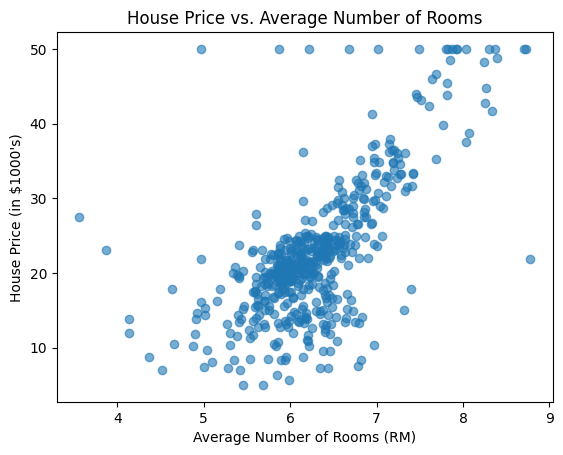

In [27]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.scatter(x, y, alpha=0.6)  # alpha=0.6 for slight transparency

# Label the axes
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price (in $1000's)")

# Optionally, add a title
plt.title("House Price vs. Average Number of Rooms")

plt.show()


## Fitting a Simple Linear Model

We will write a simple function to perform a linear fit under the squared loss function. Use the formulae given in the class to compute the optimal parameters $\beta_0,\beta_1$ in the linear model $$y =\beta_0 + \beta_1 x$$ as well as the optimal loss $\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x)^2$.

In [28]:
import numpy as np

def fit_linear(x, y):
    """
    Given vectors of data points (x,y), performs a fit for the linear model:
       y = beta0 + beta1*x,
    using ordinary least squares.

    Returns:
      beta0, beta1, loss
    where:
      beta0 = intercept
      beta1 = slope
      loss = sum of squared errors for the fitted model
    """
    # Compute means of x and y
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # Compute beta1 using the closed-form solution:
    #    beta1 = sum( (x_i - mean(x)) * (y_i - mean(y)) ) / sum( (x_i - mean(x))^2 )
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
    beta1 = numerator / denominator

    # Compute beta0
    beta0 = y_mean - beta1 * x_mean

    # Compute the sum of squared errors (loss)
    residuals = y - (beta0 + beta1 * x)
    loss = np.sum(residuals ** 2)

    return beta0, beta1, loss


Using the function `fit_linear` above, print the values `beta0`, `beta1` and `loss` for the linear model of price vs. number of rooms.

In [29]:
# Assuming x and y are defined
beta0, beta1, loss = fit_linear(x, y)

print(f"beta0 = {beta0}")
print(f"beta1 = {beta1}")
print(f"loss = {loss}")


beta0 = -34.67062077643857
beta1 = 9.10210898118031
loss = 22061.879196211798


Replot the scatter plot above, but now with the regression line.  You can create the regression line by creating points `yp` that are the predicted values for each value in `x`, according to our linear model. Plot as a line, not a scatter plot.

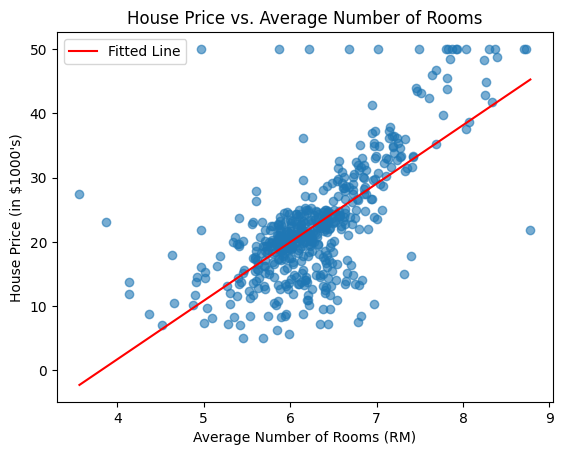

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming x, y, beta0, and beta1 are already defined
# Scatter plot of the original data
plt.scatter(x, y, alpha=0.6)

# Generate predicted values for each x
yp = beta0 + beta1 * x

# To ensure a smooth line, sort x and yp together by x
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
yp_sorted = yp[sort_idx]

# Plot the regression line
plt.plot(x_sorted, yp_sorted, color='red', label='Fitted Line')

# Label the axes
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price (in $1000's)")

# Optionally add a legend and title
plt.legend()
plt.title("House Price vs. Average Number of Rooms")

plt.show()


# Part 2:  Compare different dependent variables


We next compute the squared loss for all the predictors and output the values in a table. Your table should look like the following, where each entry in the first column is the attribute name and the second column is the squared loss.

    CRIM        XXXXX
    ZN          XXXXX
    INDUS       XXXXX
    ...         ...

You will need to write a loop. One option is to loop over the list of colunm names in the dataframe `df`.

What variable does the best job predicting house price?

In [43]:
for col in boston_df.columns:
    if col != "PRICE":
        boston_df[col] = pd.to_numeric(boston_df[col], errors="coerce")

# Then do your loop
predictor_cols = [col for col in boston_df.columns if col != "PRICE"]




**TODO:** Describe in words the meaning of the most predictive variable for housing price. You might need to do some Googling to figure out what it means.

# Part 3:  Compare different loss functions

## A Brute force algorithm for squared loss

Your code in `fit_linear` relies on the closed form expressions for the optimal $\beta_0$ and $\beta_1$, which we derived in class. However, if you did not know these formulas, you could have approximately minimized the loss function by brute force searching over a grid of possible values for $\beta_0$ and $\beta_1$. This idea was suggested by a student in our class.

For example, we could try out all combinations of parameters where $\beta_0$ is in `np.arange(-50,50,1)` and $\beta_1$ is in `np.arange(-10,10,.1)`

Write a function which takes this approach to find a $\beta_0$ and $\beta_1$ which approximately minimize the squared loss: $\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x)^2$

Closed-form solution:
  beta0=34.554, beta1=-0.950, loss=19472.381

Brute-force approximation:
  beta0=34.000, beta1=-0.900, loss=19540.082


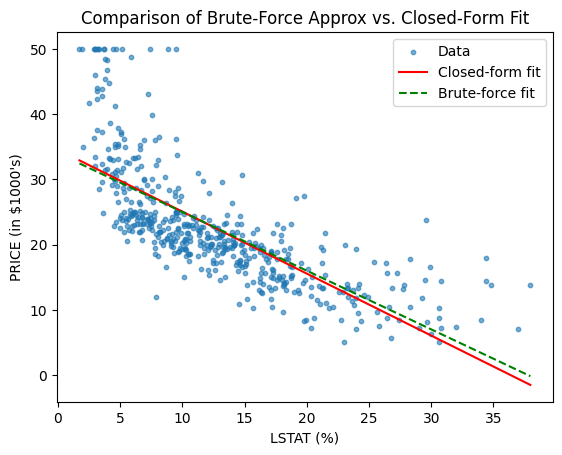

In [50]:
import numpy as np

def fit_approx(x, y):
    """
    Given vectors of data points (x,y), performs an approximate fit for
    the linear model:
        y = beta0 + beta1*x
    under the sum-of-squares loss:
        sum_{i}(y_i - beta0 - beta1*x_i)^2

    The search is done by brute force over a grid of values for beta0 and beta1.

    Returns:
      beta0, beta1, min_loss
    where:
      beta0, beta1 are the parameters that minimize the squared loss (approximately),
      min_loss is the lowest sum of squared errors found on this grid.
    """

    # Define search grids for beta0, beta1
    beta0_candidates = np.arange(-50, 50, 1.0)
    beta1_candidates = np.arange(-10, 10, 0.1)

    min_loss = np.inf
    best_beta0 = None
    best_beta1 = None

    # Brute force over all (beta0, beta1) pairs
    for b0 in beta0_candidates:
        for b1 in beta1_candidates:
            y_pred = b0 + b1 * x
            sse = np.sum((y - y_pred)**2)
            if sse < min_loss:
                min_loss = sse
                best_beta0 = b0
                best_beta1 = b1

    return best_beta0, best_beta1, min_loss

def fit_linear(x, y):
    """
    Returns the exact (beta0, beta1) solution for:
       y = beta0 + beta1*x
    minimizing sum of squares, and the SSE (loss).
    """
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    beta1 = numerator / denominator
    beta0 = y_mean - beta1 * x_mean

    residuals = y - (beta0 + beta1 * x)
    loss = np.sum(residuals**2)

    return beta0, beta1, loss

x = boston_df["LSTAT"].values
y = boston_df["PRICE"].values

# 1) Exact closed-form solution
beta0_lin, beta1_lin, loss_lin = fit_linear(x, y)
print("Closed-form solution:")
print(f"  beta0={beta0_lin:.3f}, beta1={beta1_lin:.3f}, loss={loss_lin:.3f}")

# 2) Approximate brute-force solution
beta0_approx, beta1_approx, loss_approx = fit_approx(x, y)
print("\nBrute-force approximation:")
print(f"  beta0={beta0_approx:.3f}, beta1={beta1_approx:.3f}, loss={loss_approx:.3f}")

import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(x, y, alpha=0.6, label="Data", s=10)

# Plot the closed-form line
y_pred_lin = beta0_lin + beta1_lin * x
# Sort for a continuous line
sort_idx = np.argsort(x)
plt.plot(x[sort_idx], y_pred_lin[sort_idx], color="red", label="Closed-form fit")

# Plot the brute-force approximate line
y_pred_approx = beta0_approx + beta1_approx * x
plt.plot(x[sort_idx], y_pred_approx[sort_idx], color="green", label="Brute-force fit", linestyle="--")

plt.xlabel("LSTAT (%)")
plt.ylabel("PRICE (in $1000's)")
plt.title("Comparison of Brute-Force Approx vs. Closed-Form Fit")
plt.legend()
plt.show()



Compare the output of `fit_approx` and `fit_linear` with `y` being `PRICE` and `x` being the `LSAT` variable from our dataset. You should do so:
* quantitatively, by printing the loss that each approach achieves
* and visually, by plotting the different fit lines obtained.

## Extending to different loss functions

One benefit of the above approach is that is easily extends to different loss funtions. Write functions which find an approximately optimal $\beta_0$ and $\beta_1$ for
* minimizing the $\ell_1$ (least absolute deviations) loss: $\sum_{i=1}^n |y_i - \beta_0 - \beta_1 x|$
* minimizing the $\ell_\infty$ (max) loss: $\max_i |y_i - \beta_0 - \beta_1 x|$


** L2 fit **  beta0=34.55, beta1=-0.95, loss=19472.38
** L1 fit **  beta0=31.00, beta1=-0.80, loss=2163.56
** L∞ fit **  beta0=37.00, beta1=-0.70, loss=19.67


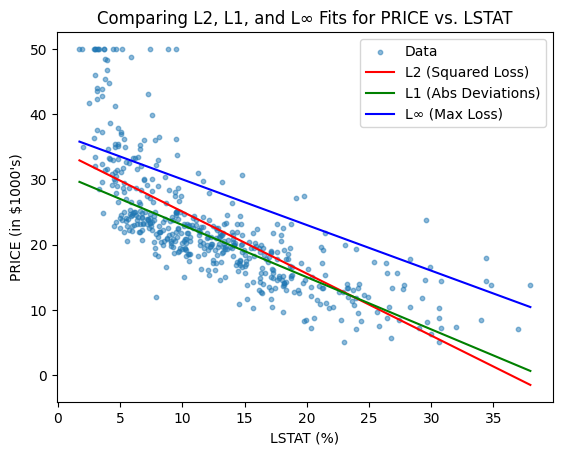

In [54]:
import numpy as np

def fit_approx_l1(x, y):
    """
    Given vectors of data points (x,y), performs a *brute-force* fit
    for the linear model y = beta0 + beta1*x under the L1 loss:
        sum_i |y_i - beta0 - beta1*x_i|

    Returns:
      (beta0, beta1, min_loss)
    where:
      beta0, beta1 are the best intercept/slope found,
      min_loss is the lowest sum of absolute residuals on that grid.
    """
    beta0_candidates = np.arange(-50, 50, 1.0)
    beta1_candidates = np.arange(-10, 10, 0.1)

    min_loss = np.inf
    best_beta0 = None
    best_beta1 = None

    # Brute-force over the grid
    for b0 in beta0_candidates:
        for b1 in beta1_candidates:
            # Compute sum of absolute deviations
            residuals = y - (b0 + b1 * x)
            loss_l1 = np.sum(np.abs(residuals))
            if loss_l1 < min_loss:
                min_loss = loss_l1
                best_beta0 = b0
                best_beta1 = b1

    return best_beta0, best_beta1, min_loss

import matplotlib.pyplot as plt

# Step 1: Extract your data (predictor LSTAT, response PRICE).
x = boston_df["LSTAT"].values
y = boston_df["PRICE"].values

# Step 2: Fit each model

# 2a. L2 (squared loss) — using a closed-form function or your own "fit_linear"
beta0_l2, beta1_l2, loss_l2 = fit_linear(x, y)
print(f"** L2 fit **  beta0={beta0_l2:.2f}, beta1={beta1_l2:.2f}, loss={loss_l2:.2f}")

# 2b. L1 (absolute deviations)
beta0_l1, beta1_l1, loss_l1 = fit_approx_l1(x, y)
print(f"** L1 fit **  beta0={beta0_l1:.2f}, beta1={beta1_l1:.2f}, loss={loss_l1:.2f}")

# 2c. L∞ (max loss)
beta0_inf, beta1_inf, loss_inf = fit_approx_max(x, y)
print(f"** L∞ fit **  beta0={beta0_inf:.2f}, beta1={beta1_inf:.2f}, loss={loss_inf:.2f}")

# Step 3: Plot

# 3a. Scatter plot of data
plt.scatter(x, y, alpha=0.5, label="Data", s=10)

# For plotting lines, let's sort by x to avoid zig-zag lines
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

# 3b. Predicted values for each model
y_pred_l2 = beta0_l2 + beta1_l2 * x_sorted
y_pred_l1 = beta0_l1 + beta1_l1 * x_sorted
y_pred_inf = beta0_inf + beta1_inf * x_sorted

# 3c. Plot the lines
plt.plot(x_sorted, y_pred_l2, label="L2 (Squared Loss)", color="red")
plt.plot(x_sorted, y_pred_l1, label="L1 (Abs Deviations)", color="green")
plt.plot(x_sorted, y_pred_inf, label="L∞ (Max Loss)", color="blue")

# Labels and legend
plt.xlabel("LSTAT (%)")
plt.ylabel("PRICE (in $1000's)")
plt.title("Comparing L2, L1, and L∞ Fits for PRICE vs. LSTAT")
plt.legend()
plt.show()



L2 (Squared Loss) -> beta0=34.554, beta1=-0.950, SSE=19472.381
L1 (Abs Deviations) -> beta0=31.000, beta1=-0.800, sum_abs_res=2163.560
L∞ (Max Loss) -> beta0=37.000, beta1=-0.700, max_abs_res=19.671


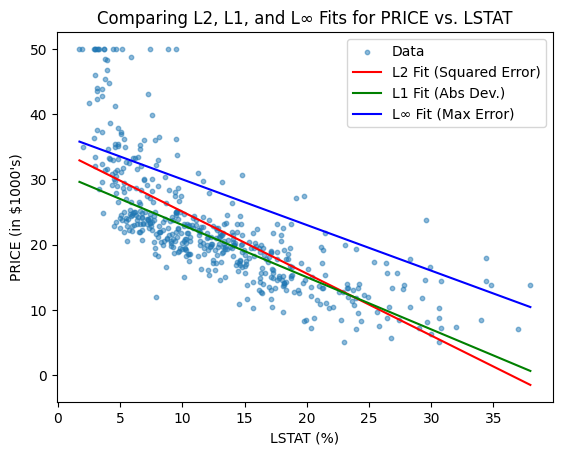

In [55]:
import numpy as np

def fit_approx_max(x, y):
    """
    Given vectors of data points (x, y), performs a *brute-force* search for
    the parameters (beta0, beta1) that minimize the max absolute error:

        max_i |y_i - (beta0 + beta1 * x_i)|.

    Returns:
      beta0, beta1, min_loss

    where min_loss is the smallest maximum absolute error found on the search grid.
    """
    # Candidate ranges for beta0 (intercept) and beta1 (slope)
    beta0_candidates = np.arange(-50, 50, 1.0)
    beta1_candidates = np.arange(-10, 10, 0.1)

    min_loss = np.inf
    best_beta0 = None
    best_beta1 = None

    # Brute-force search
    for b0 in beta0_candidates:
        for b1 in beta1_candidates:
            # Compute the absolute residuals for all data points
            residuals = np.abs(y - (b0 + b1 * x))
            # We want to minimize the maximum absolute residual
            loss_max = np.max(residuals)
            if loss_max < min_loss:
                min_loss = loss_max
                best_beta0 = b0
                best_beta1 = b1

    return best_beta0, best_beta1, min_loss
import matplotlib.pyplot as plt

# Extract data (predictor LSTAT, response PRICE)
x = boston_df["LSTAT"].values
y = boston_df["PRICE"].values

# -- 1) L2 (Squared Loss) --
beta0_l2, beta1_l2, loss_l2 = fit_linear(x, y)
print(f"L2 (Squared Loss) -> beta0={beta0_l2:.3f}, beta1={beta1_l2:.3f}, SSE={loss_l2:.3f}")

# -- 2) L1 (Absolute Deviations) --
beta0_l1, beta1_l1, loss_l1 = fit_approx_l1(x, y)
print(f"L1 (Abs Deviations) -> beta0={beta0_l1:.3f}, beta1={beta1_l1:.3f}, sum_abs_res={loss_l1:.3f}")

# -- 3) L∞ (Max Loss) --
beta0_inf, beta1_inf, loss_inf = fit_approx_max(x, y)
print(f"L∞ (Max Loss) -> beta0={beta0_inf:.3f}, beta1={beta1_inf:.3f}, max_abs_res={loss_inf:.3f}")

# Scatter plot of data
plt.scatter(x, y, alpha=0.5, label="Data", s=10)

# Sort x for continuous line plots
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

# Predicted values for each fit
y_pred_l2 = beta0_l2 + beta1_l2 * x_sorted
y_pred_l1 = beta0_l1 + beta1_l1 * x_sorted
y_pred_inf = beta0_inf + beta1_inf * x_sorted

# Plot the lines
plt.plot(x_sorted, y_pred_l2, label="L2 Fit (Squared Error)", color="red")
plt.plot(x_sorted, y_pred_l1, label="L1 Fit (Abs Dev.)", color="green")
plt.plot(x_sorted, y_pred_inf, label="L∞ Fit (Max Error)", color="blue")

# Add labels, legend, and title
plt.xlabel("LSTAT (%)")
plt.ylabel("PRICE (in $1000's)")
plt.title("Comparing L2, L1, and L∞ Fits for PRICE vs. LSTAT")
plt.legend()
plt.show()


Use your algorithm to obtain 3 different linear fits for `PRICE` with predictor variable `LSTAT`, one for squared loss, one for $\ell_1$ loss, and one for $\ell_\infty$ loss. Plot the linear fits (along with the data scatter plot) on a single figure and use a legend to indicate which fit corresponds to which loss.